In [13]:
import pathlib

import numpy as np
import pandas as pd

In [14]:
output_folder = pathlib.Path("../../data/outputs/")
prediction_runs = [fol for fol in output_folder.iterdir() if fol.is_dir()]
prediction_runs

[PosixPath('../../data/outputs/biolog_mutual_info_1000'),
 PosixPath('../../data/outputs/biolog'),
 PosixPath('../../data/outputs/biolog_pca_100'),
 PosixPath('../../data/outputs/biolog_pca_200'),
 PosixPath('../../data/outputs/biolog_chi2_1000'),
 PosixPath('../../data/outputs/biolog_nmf_200'),
 PosixPath('../../data/outputs/biolog_nmf_100'),
 PosixPath('../../data/outputs/biolog_f_500'),
 PosixPath('../../data/outputs/biolog_chi2_500'),
 PosixPath('../../data/outputs/biolog_mutual_info_500'),
 PosixPath('../../data/outputs/biolog_f_1000')]

In [15]:
def read_csv_files(folder_list: list[pathlib.Path], file_name: str, reindex: bool = True):
    df_list = []
    for folder in folder_list:
        file_path = folder / file_name
        df = pd.read_csv(file_path, index_col=0)
        df_list.append(df)
    df_concat = pd.concat(df_list)
    if reindex:
        df_concat.index = list(range(df_concat.shape[0])) # type: ignore
    return df_concat

In [16]:
scores_df = read_csv_files(prediction_runs, "all_feat_scores_data.csv", reindex=True)
scores_df

,name,category,accuracy,balanced_accuracy,f1,precision,recall,matthews_corrcoef,class_0,class_1,feature,run_id
0,Carbon-Dextrin,ch_biolog,0.733333,0.703704,0.625000,0.714286,0.555556,0.431124,178,119,cluster30,biolog_mutual_info_1000
1,Carbon-Salicin,ch_biolog,0.773810,0.773965,0.771084,0.761905,0.780488,0.547774,144,136,cluster30,biolog_mutual_info_1000
2,Carbon-L-Fucose,ch_biolog,0.875000,0.828125,0.785714,0.916667,0.687500,0.714435,106,53,cluster30,biolog_mutual_info_1000
3,Carbon-a-Hydroxy-Butyric-Acid,ch_biolog,0.771739,0.770952,0.787879,0.795918,0.780000,0.541004,140,164,cluster30,biolog_mutual_info_1000
4,Carbon-D-Raffinose,ch_biolog,0.745098,0.725146,0.657895,0.806452,0.555556,0.486103,190,150,cluster30,biolog_mutual_info_1000
...,...,...,...,...,...,...,...,...,...,...,...,...
2107,Carbon-Acetic-Acid,ch_biolog,0.886364,0.543750,0.939024,0.916667,0.962500,0.120761,26,266,uniref90,biolog_f_1000
2108,Carbon-b-Methyl-D-Glucoside,ch_biolog,0.773810,0.752288,0.825688,0.714286,0.978261,0.579987,127,153,uniref90,biolog_f_1000
2109,Carbon-Citric-Acid,ch_biolog,0.795699,0.744444,0.854962,0.823529,0.888889,0.515486,98,210,uniref90,biolog_f_1000
2110,Carbon-D-Trehalose,ch_biolog,0.768421,0.735227,0.825397,0.732394,0.945455,0.534557,132,183,uniref90,biolog_f_1000


In [17]:
cv_scores_df = read_csv_files(prediction_runs, "all_feat_cv_scores_data.csv", reindex=True)
cv_scores_df

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,matthews_corrcoef,name,category,fold_num,feature,run_id
0,0.766667,0.708333,1.000000,0.416667,0.588235,0.870370,0.547723,Carbon-Dextrin,ch_biolog,1,cluster30,biolog_mutual_info_1000
1,0.450000,0.486111,0.390244,0.666667,0.492308,0.627315,-0.029254,Carbon-Dextrin,ch_biolog,2,cluster30,biolog_mutual_info_1000
2,0.661017,0.642262,0.590909,0.541667,0.565217,0.635714,0.289032,Carbon-Dextrin,ch_biolog,3,cluster30,biolog_mutual_info_1000
3,0.610169,0.645238,0.512821,0.833333,0.634921,0.672619,0.301441,Carbon-Dextrin,ch_biolog,4,cluster30,biolog_mutual_info_1000
4,0.847458,0.827899,0.850000,0.739130,0.790698,0.855072,0.675674,Carbon-Dextrin,ch_biolog,5,cluster30,biolog_mutual_info_1000
...,...,...,...,...,...,...,...,...,...,...,...,...
10555,0.649123,0.654557,0.909091,0.344828,0.500000,0.876847,0.391580,Carbon-a-D-Lactose,ch_biolog,1,uniref90,biolog_f_1000
10556,0.754386,0.754926,0.777778,0.724138,0.750000,0.842980,0.510481,Carbon-a-D-Lactose,ch_biolog,2,uniref90,biolog_f_1000
10557,0.736842,0.734606,0.694444,0.862069,0.769231,0.819581,0.486280,Carbon-a-D-Lactose,ch_biolog,3,uniref90,biolog_f_1000
10558,0.754386,0.754926,0.733333,0.785714,0.758621,0.810961,0.510481,Carbon-a-D-Lactose,ch_biolog,4,uniref90,biolog_f_1000


In [18]:
cv_features_df = read_csv_files(prediction_runs, "all_feat_cv_features_data.csv", reindex=True)
cv_features_df

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_16,feat_17,feat_18,feat_19,feat_20,fold_num,feature,run_id,name,category
0,427_1360,795_3506,394_7066,519_4729,179_1334,117_3377,588_622,77_731,560_4532,674_4452,...,748_2663,77_6856,708_6603,95_1179,312_1904,1,cluster30,biolog_mutual_info_1000,Carbon-Dextrin,ch_biolog
1,427_1360,519_4729,795_3506,216_4414,943_4698,950_1835,284_2239,588_622,504_841,674_4452,...,397_2265,560_4532,284_2025,329_3222,312_1904,2,cluster30,biolog_mutual_info_1000,Carbon-Dextrin,ch_biolog
2,943_4698,708_6603,117_3377,588_622,394_7066,363_1654,427_1360,146_1079,795_3506,400_395,...,284_2025,254_2432,327_617,86_4219,299_891,3,cluster30,biolog_mutual_info_1000,Carbon-Dextrin,ch_biolog
3,427_1360,519_4729,943_4698,708_6603,875_4225,312_1904,588_622,123_4122,284_1265,259_795,...,288_1904,674_4452,947_5262,471_3954,216_4414,4,cluster30,biolog_mutual_info_1000,Carbon-Dextrin,ch_biolog
4,427_1360,795_3506,548_966,588_622,261_3613,943_4698,312_1904,288_1904,77_731,504_841,...,442_3383,39_3435,757_878,688_1099,394_7066,5,cluster30,biolog_mutual_info_1000,Carbon-Dextrin,ch_biolog
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10555,UniRef90_A0A1G9KIJ9,UniRef90_C6DJH0,UniRef90_A0A0Q8RQT0,UniRef90_Q6FF90,UniRef90_V5VAJ9,UniRef90_V5VDS0,UniRef90_B7H0A7,UniRef90_A0A0F4FN05,UniRef90_A0A7X5QV47,UniRef90_V5VC36,...,UniRef90_Q7N1X3,UniRef90_A0A4P7SQC7,UniRef90_P0A2S0,UniRef90_A0A087NSA7,UniRef90_A0A086WC51,1,uniref90,biolog_f_1000,Carbon-a-D-Lactose,ch_biolog
10556,UniRef90_A0A0F4FN05,UniRef90_Q7N1X3,UniRef90_A0A087NSA7,UniRef90_A0A1I7CB70,UniRef90_A6T3K8,UniRef90_Q8EJE5,UniRef90_Q57T37,UniRef90_UPI001AE412D1,UniRef90_A0A1G9KIJ9,UniRef90_G8PY90,...,UniRef90_P0A9P2,UniRef90_B0RRB8,UniRef90_A0A1T5BMN9,UniRef90_UPI001F03AA0E,UniRef90_A0A1K1P946,2,uniref90,biolog_f_1000,Carbon-a-D-Lactose,ch_biolog
10557,UniRef90_B1FUE9,UniRef90_B1G3V2,UniRef90_Q6FF90,UniRef90_A0A1G9KIJ9,UniRef90_A0A087NSA7,UniRef90_V5VDS0,UniRef90_A0A7X0GGL3,UniRef90_A0A0Q8RQT0,UniRef90_A0A1K1P946,UniRef90_UPI001AE412D1,...,UniRef90_A0A3S9X6W4,UniRef90_A0A7X5QV47,UniRef90_Q8EJE5,UniRef90_A1R8T1,UniRef90_T1XDB6,3,uniref90,biolog_f_1000,Carbon-a-D-Lactose,ch_biolog
10558,UniRef90_B1FUE9,UniRef90_A0A0F4FN05,UniRef90_V5VDS0,UniRef90_A0A1G9KIJ9,UniRef90_C6DJH0,UniRef90_B7H0A7,UniRef90_Q8EJE5,UniRef90_A0A087NSA7,UniRef90_B1G3V2,UniRef90_Q6FF90,...,UniRef90_UPI001AE412D1,UniRef90_T1XDB6,UniRef90_A0A7V8JHT2,UniRef90_A1R8T1,UniRef90_A0A1N7SAE8,4,uniref90,biolog_f_1000,Carbon-a-D-Lactose,ch_biolog


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

Plot std of metrics in each cross validation

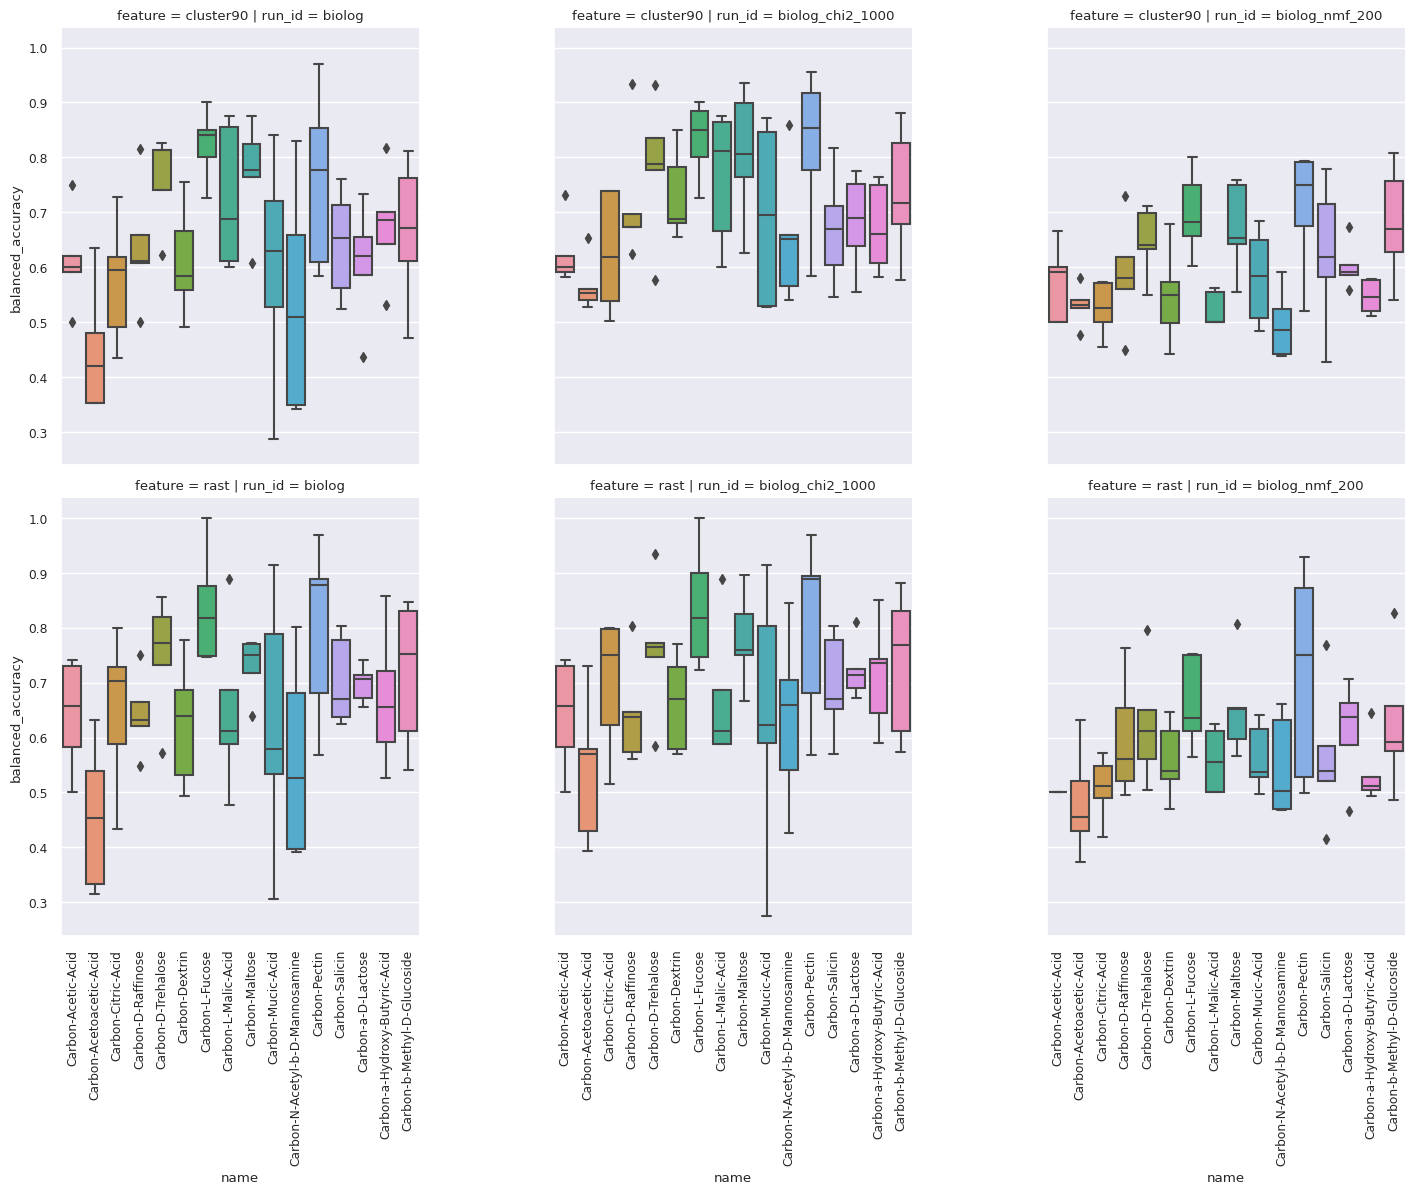

In [96]:
plot_data = cv_scores_df[(cv_scores_df.feature.isin(["rast", "cluster90"])) & (cv_scores_df.run_id.isin(["biolog", "biolog_chi2_1000", "biolog_nmf_200"]))]
name_order = plot_data.groupby(by=["name"])["balanced_accuracy"].mean().reset_index().name
g = sns.catplot(data=plot_data, x="name", y="balanced_accuracy", kind="box", col="run_id", row="feature", order=name_order)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=90, which="both");

In [98]:
def common_features(group):
    df = group.drop(["fold_num", "category", "feature", "run_id", "name"], axis=1)
    n = df.shape[0]
    m = df.shape[1]
    feature_list = []
    for i in range(n):
        feature_list.append(set(df.iloc[i]))
    common_features = set.intersection(*feature_list)
    return len(common_features) / m

/tmp/nix-shell.bsXfdd/ipykernel_1573838/536260732.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  plot_data = cv_features_df[(cv_features_df.feature == "rast") & (cv_features_df.run_id.isin(["biolog", "biolog_chi2_1000", "biolog_nmf_200"]))].groupby(by=["run_id", "name"]).apply(common_features).reset_index()


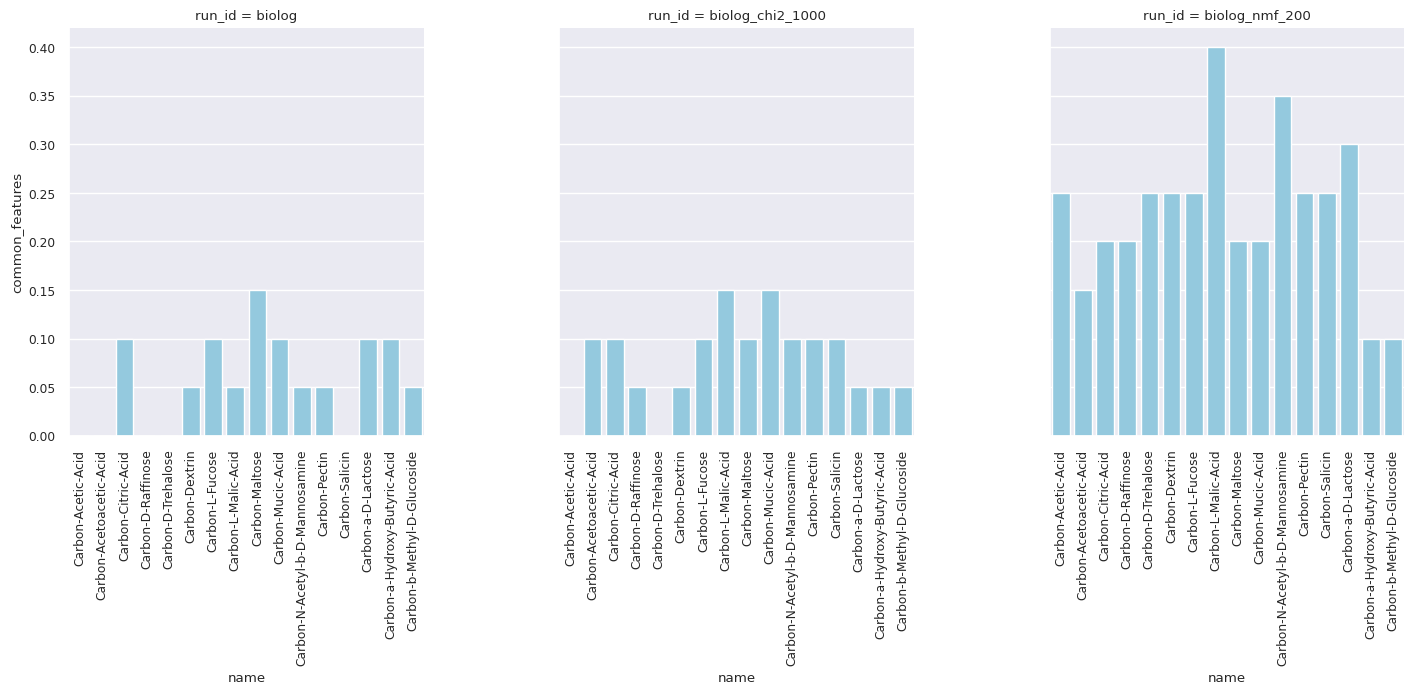

In [101]:
plot_data = cv_features_df[(cv_features_df.feature == "rast") & (cv_features_df.run_id.isin(["biolog", "biolog_chi2_1000", "biolog_nmf_200"]))].groupby(by=["run_id", "name"]).apply(common_features).reset_index()
plot_data.columns = ["run_id", "name", "common_features"]
g = sns.catplot(data=plot_data, x="name", y="common_features", kind="bar", col="run_id", col_wrap=3, color="skyblue", order=name_order)
# plt.ylim(0, 1)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=90, which="both");

In [61]:
cv_scores_melt = cv_scores_df.melt(id_vars=["run_id", "name", "feature", "fold_num", "category"], value_vars=["accuracy", "balanced_accuracy", "f1", "precision", "recall", "matthews_corrcoef"], var_name="metric")
cv_scores_melt

,run_id,name,feature,fold_num,category,metric,value
0,biolog_mutual_info_1000,Carbon-Dextrin,cluster30,1,ch_biolog,accuracy,0.766667
1,biolog_mutual_info_1000,Carbon-Dextrin,cluster30,2,ch_biolog,accuracy,0.450000
2,biolog_mutual_info_1000,Carbon-Dextrin,cluster30,3,ch_biolog,accuracy,0.661017
3,biolog_mutual_info_1000,Carbon-Dextrin,cluster30,4,ch_biolog,accuracy,0.610169
4,biolog_mutual_info_1000,Carbon-Dextrin,cluster30,5,ch_biolog,accuracy,0.847458
...,...,...,...,...,...,...,...
63355,biolog_f_1000,Carbon-a-D-Lactose,uniref90,1,ch_biolog,matthews_corrcoef,0.391580
63356,biolog_f_1000,Carbon-a-D-Lactose,uniref90,2,ch_biolog,matthews_corrcoef,0.510481
63357,biolog_f_1000,Carbon-a-D-Lactose,uniref90,3,ch_biolog,matthews_corrcoef,0.486280
63358,biolog_f_1000,Carbon-a-D-Lactose,uniref90,4,ch_biolog,matthews_corrcoef,0.510481


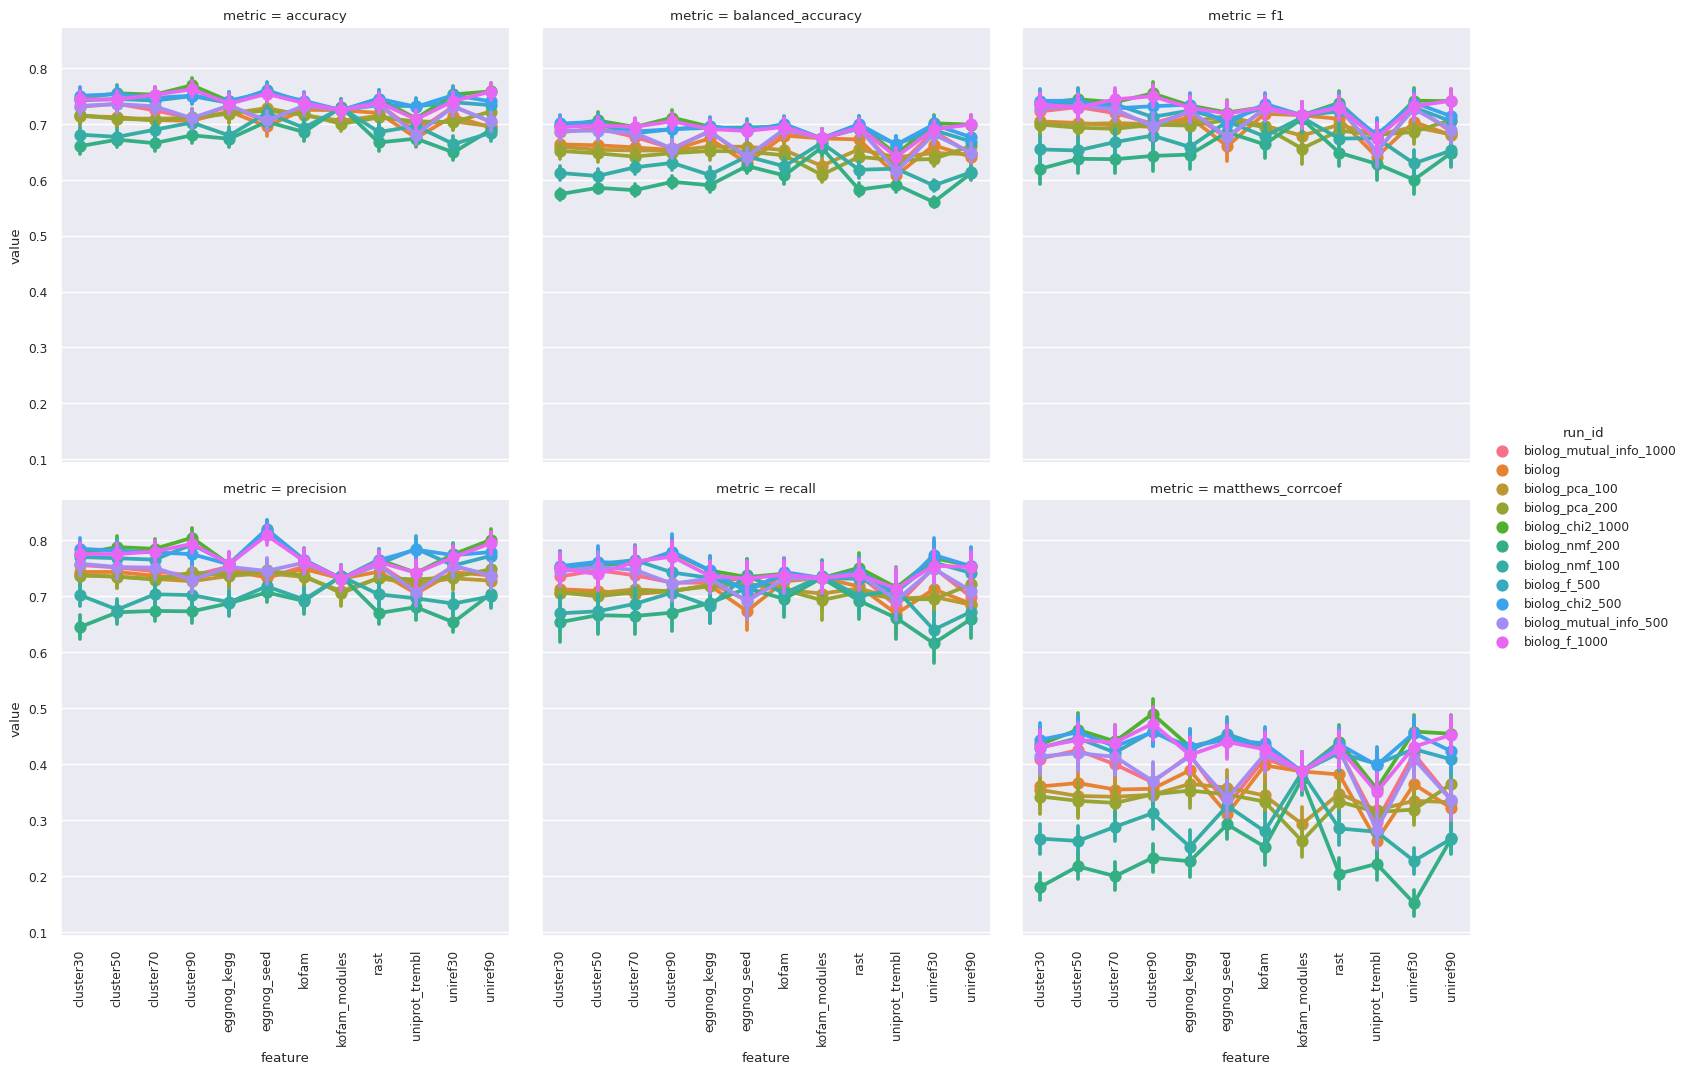

In [88]:
plot_data = cv_scores_melt
palette = sns.color_palette("husl", 12)
g = sns.catplot(data=plot_data, x="feature", y="value", errorbar="se", kind="point", col="metric", col_wrap=3, hue="run_id", palette=palette)
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=90, which="both");

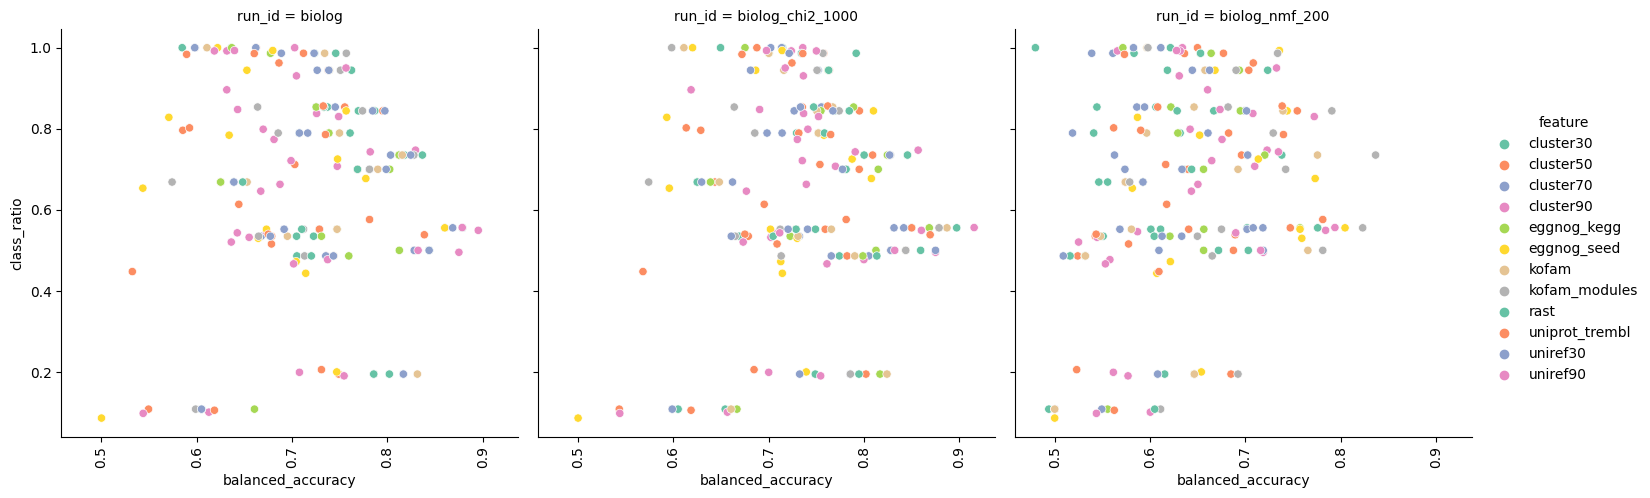

In [67]:
plot_data = scores_df.copy()
plot_data = plot_data[plot_data.run_id.isin(["biolog", "biolog_chi2_1000", "biolog_nmf_200"])]
plot_data["class_ratio"] = plot_data.apply(lambda x: min(x["class_1"], x["class_0"]) / max(x["class_1"], x["class_0"]), axis=1)
g = sns.relplot(data=plot_data, x="balanced_accuracy", y="class_ratio", kind="scatter", col="run_id", col_wrap=3, hue="feature", palette="Set2")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=90, which="both");

In [70]:
cv_scores_df.groupby(by=["run_id", "feature", "name"])["balanced_accuracy"].mean().reset_index().sort_values(by="balanced_accuracy", ascending=False).head(10)

,run_id,feature,name,balanced_accuracy
998,biolog_mutual_info_1000,cluster70,Carbon-L-Fucose,0.865931
806,biolog_f_500,cluster70,Carbon-L-Fucose,0.860476
1158,biolog_mutual_info_500,cluster30,Carbon-L-Fucose,0.860476
1334,biolog_mutual_info_500,uniref90,Carbon-L-Fucose,0.860292
1126,biolog_mutual_info_1000,uniref30,Carbon-L-Fucose,0.856840
1174,biolog_mutual_info_500,cluster50,Carbon-L-Fucose,0.855714
374,biolog_chi2_1000,uniref90,Carbon-L-Fucose,0.855029
758,biolog_f_1000,uniref90,Carbon-L-Fucose,0.855029
1318,biolog_mutual_info_500,uniref30,Carbon-L-Fucose,0.852511
1094,biolog_mutual_info_1000,rast,Carbon-L-Fucose,0.851861


In [82]:
cv_bac_scores = cv_scores_melt[(cv_scores_melt.metric == "balanced_accuracy") & (cv_scores_melt.feature == "rast")].groupby(by=["run_id", "name"])["value"].mean().reset_index().sort_values(by="value", ascending=False).pivot(index="name", columns="run_id", values="value")
cv_bac_scores

run_id,biolog,biolog_chi2_1000,biolog_chi2_500,biolog_f_1000,biolog_f_500,biolog_mutual_info_1000,biolog_mutual_info_500,biolog_nmf_100,biolog_nmf_200,biolog_pca_100,biolog_pca_200
name,,,,,,,,,,,
Carbon-Acetic-Acid,0.642488,0.642488,0.640601,0.642488,0.642488,0.659154,0.662488,0.583333,0.500000,0.597834,0.577708
Carbon-Acetoacetic-Acid,0.454615,0.541077,0.533538,0.494000,0.497385,0.486000,0.482462,0.488769,0.482000,0.477385,0.438308
Carbon-Citric-Acid,0.650398,0.697204,0.690116,0.680862,0.690766,0.671607,0.702235,0.529231,0.508079,0.652343,0.585999
Carbon-D-Raffinose,0.642632,0.644561,0.643158,0.638596,0.652456,0.649298,0.632632,0.585439,0.598596,0.591053,0.611579
Carbon-D-Trehalose,0.750427,0.760571,0.754094,0.743507,0.731564,0.764417,0.760714,0.658375,0.624959,0.711306,0.696956
Carbon-Dextrin,0.625835,0.663709,0.663970,0.648772,0.642167,0.647167,0.645438,0.568880,0.558366,0.588801,0.529607
Carbon-L-Fucose,0.838009,0.837576,0.842338,0.838009,0.833463,0.851861,0.846623,0.771645,0.663247,0.804589,0.766623
Carbon-L-Malic-Acid,0.650833,0.673056,0.690833,0.717500,0.735278,0.735278,0.708611,0.621944,0.558333,0.617500,0.584167
Carbon-Maltose,0.730230,0.779179,0.783884,0.788589,0.774775,0.772072,0.789289,0.702799,0.655484,0.780581,0.804505


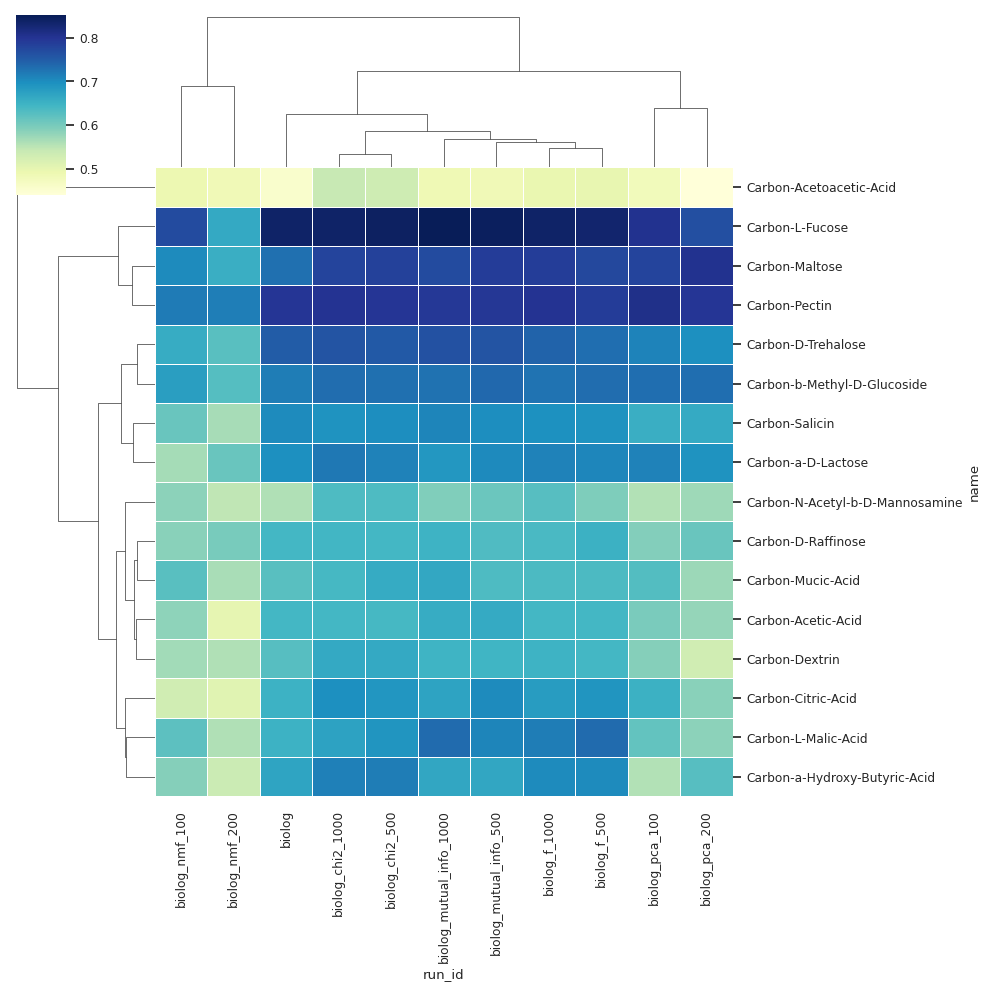

In [83]:
plot_data = cv_bac_scores
sns.set(font_scale=0.8)
sns.clustermap(plot_data,  linewidths=.5, cmap="YlGnBu", yticklabels=1)